In [ ]:
# Import Libraries
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df=pd.read_csv("Student_performance_data _.csv")

In [ ]:
df.dtypes

,0
StudentID,int64
Age,int64
Gender,int64
Ethnicity,int64
ParentalEducation,int64
StudyTimeWeekly,float64
Absences,int64
Tutoring,int64
ParentalSupport,int64
Extracurricular,int64


In [ ]:
# TASK 1
df['GradeClass'] = df['GradeClass'].astype(int)
binary_cols = ['Gender', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
for col in binary_cols:
    df[col] = df[col].astype('category')
df['GPA'] = df['GPA'].round(2)
df['StudyTimeWeekly'] = df['StudyTimeWeekly'].round(2)

print(df.dtypes)
df.head()

StudentID               int64
Age                     int64
Gender               category
Ethnicity               int64
ParentalEducation       int64
StudyTimeWeekly       float64
Absences                int64
Tutoring             category
ParentalSupport      category
Extracurricular      category
Sports               category
Music                category
Volunteering         category
GPA                   float64
GradeClass              int64
dtype: object


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.83,7,1,2,0,0,1,0,2.93,2
1,1002,18,0,0,1,15.41,0,0,1,0,0,0,0,3.04,1
2,1003,15,0,2,3,4.21,26,0,2,0,0,0,0,0.11,4
3,1004,17,1,0,3,10.03,14,0,3,1,0,0,0,2.05,3
4,1005,17,1,0,2,4.67,17,1,3,0,0,0,0,1.29,4


In [ ]:
# TASK 2
missing_count = df.isnull().sum()
print("Missing valuse count:", missing_count)

#As we can see no missing valuse are there but am going to apply (Median Imputation)
'''Mean Imputation was used to handle missing values in numerical columns like GPA.
This strategy helps maintain the overall sample size and provides a neutral estimate that
does not significantly shift the central tendency of the data.'''

df['GPA'] = df['GPA'].fillna(df['GPA'].mean())
df['StudyTimeWeekly'] = df['StudyTimeWeekly'].fillna(df['StudyTimeWeekly'].mean())


Missing valuse count: StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


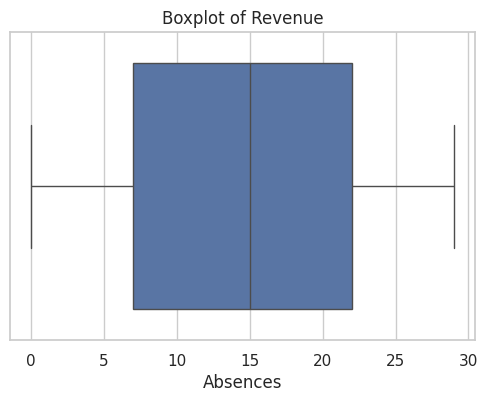

In [ ]:
# TASK 3
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Absences'])
plt.title("Boxplot of Revenue")
plt.show()

In [ ]:
# TASK 3
target_column = 'Absences'
Q1 = df[target_column].quantile(0.25)
Q3 = df[target_column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[target_column] < lower_bound) | (df[target_column] > upper_bound)]

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(outliers)}")

df_cleaned = df[(df[target_column] >= lower_bound) & (df[target_column] <= upper_bound)]

print(f"Original Size: {len(df)}")
print(f"Cleaned Size: {len(df_cleaned)}")

Lower Bound: -15.5
Upper Bound: 44.5
Number of Outliers: 0
Original Size: 2392
Cleaned Size: 2392


In [ ]:
# TASK 4
from sklearn.preprocessing import MinMaxScaler, StandardScaler

num_cols=['Age','StudyTimeWeekly','Absences','GPA']

min_max_scaler = MinMaxScaler()
df_min_max = df_cleaned.copy()
df_min_max[num_cols] = min_max_scaler.fit_transform(df_cleaned[num_cols])

standard_scaler = StandardScaler()
df_zscore = df_cleaned.copy()
df_zscore[num_cols] = standard_scaler.fit_transform(df_cleaned[num_cols])

print("Min-Max Scaled Data:")
print(df_min_max[num_cols].head())

print("\nZ-score Normalized Data:")
print(df_zscore[num_cols].head())

Min-Max Scaled Data:
        Age  StudyTimeWeekly  Absences     GPA
0  0.666667         0.992492  0.241379  0.7325
1  1.000000         0.771271  0.000000  0.7600
2  0.000000         0.210711  0.896552  0.0275
3  0.666667         0.502002  0.482759  0.5125
4  0.666667         0.233734  0.586207  0.3225

Z-score Normalized Data:
        Age  StudyTimeWeekly  Absences       GPA
0  0.472919         1.779673 -0.890822  1.118947
1  1.362944         0.997590 -1.717694  1.239166
2 -1.307132        -0.984158  1.353542 -1.963017
3  0.472919         0.045643 -0.063951  0.157200
4  0.472919        -0.902765  0.290422 -0.673401


In [ ]:
# TASK 5

features = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']
x = df_zscore[features]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(x)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_) * 100, "%")
print("\nFirst 5 rows of PCA components:")
print(pca_df.head())

Explained Variance Ratio: [0.48373823 0.25269873]
Total Variance Explained: 73.64369560004265 %

First 5 rows of PCA components:
        PC1       PC2
0  1.643360  0.933428
1  2.209176 -0.344926
2 -2.466315  0.255917
3  0.165246 -0.272886
4 -0.790755 -0.951333
